<b style="font-size: 34px; color: black;"> Python: Pandas </b> 

# Objectif de cette section

L'un des facteurs de succès de Python résident dans ses bibliothèques spécialisées.  

**L'objectif de cette section est de se familiariser avec la bibliothèque du language Python `Pandas`.**

Parmi les sources ayant servi à réaliser ce document:

* Wes McKinney's book "Python for Data Analysis" O'REILLY. Licensed under [CC BY 4.0 Creative Commons](http://creativecommons.org/licenses/by/4.0/)
* Python pour le Data Scientist - Emmanuel Jakobowicz

<b style="font-size: 14px;">Ce document sera rédigé en français et en anglais. We apologize for the inconvenience.</b> 

# Data Analysis with Pandas


Pandas est une bibliothèque Python puissante et flexible pour **la manipulation et l'analyse de données.**  
Elle fournit des structures de données de haut niveau, telles que les **DataFrame** et les **Series**, qui permettent de manipuler facilement des données tabulaires et non tabulaires.

Pandas est particulièrement utile pour les tâches suivantes :

* Nettoyage et préparation des données : Pandas fournit des fonctions pour gérer les valeurs manquantes, supprimer les doublons, filtrer et trier les données, etc.
* Manipulation de données tabulaires : Pandas fournit des fonctions pour fusionner, joindre, pivoter et agréger des données tabulaires.
* Analyse de séries temporelles : Pandas fournit des fonctions pour gérer les séries temporelles, telles que le rééchantillonnage, l'interpolation et le calcul de statistiques descriptives.
* Visualisation de données : Bien que Pandas ne soit pas principalement conçu pour la visualisation de données, il fournit des fonctions de base pour tracer des graphiques à partir de données dans des DataFrame et des Series. Il est également facile d'intégrer Pandas avec d'autres bibliothèques de visualisation de données, telles que Matplotlib et Seaborn.


# Importer le package Pandas

Pandas provides two fundamental data objects, for 1D (``Series``) and 2D data (``DataFrame``).

In [2]:
# THE standard way of importing pandas

import pandas as pd

In [4]:
pd?

Type:        module
String form: <module 'pandas' from '/opt/anaconda3/lib/python3.11/site-packages/pandas/__init__.py'>
File:        /opt/anaconda3/lib/python3.11/site-packages/pandas/__init__.py
Docstring:  
pandas - a powerful data analysis and manipulation library for Python

**pandas** is a Python package providing fast, flexible, and expressive data
structures designed to make working with "relational" or "labeled" data both
easy and intuitive. It aims to be the fundamental high-level building block for
doing practical, **real world** data analysis in Python. Additionally, it has
the broader goal of becoming **the most powerful and flexible open source data
analysis / manipulation tool available in any language**. It is already well on
its way toward this goal.

Main Features
-------------
Here are just a few of the things that pandas does well:

  - Easy handling of missing data in floating point as well as non-floating
    point data.
  - Size mutability: columns can be inserte

In [13]:
# Dans cette section nous utliserons également NumPy

import numpy as np

# Data structures

Pandas provides two fundamental data objects, for 1D (``Series``) and 2D data (``DataFrame``).

## Series: Uni-dimensional Data

Une série est un conteneur de base pour des données étiquetées à une dimension. Elle peut être créée de la même manière qu'un tableau NumPy:

In [14]:
s = pd.Series([0.1, 0.2, 0.3, 0.4])
s

0    0.1
1    0.2
2    0.3
3    0.4
dtype: float64

In [15]:
type(s)

pandas.core.series.Series

### Attributs des Series: `index` et `values`

The series has a built-in concept of an **index**, which by default is the numbers *0* through *N - 1*

In [16]:
s.index

RangeIndex(start=0, stop=4, step=1)

You can access the underlying numpy array representation with the `.values` attribute:

In [17]:
s.values

array([0.1, 0.2, 0.3, 0.4])

In [18]:
type(s.values)

numpy.ndarray

We can access series values via the index, just like for NumPy arrays:

In [19]:
s[0]

0.1

Contrairement aux tableaux the NumPy, ces indexes peuvent être quelque chose d'autre que des entiers:

In [20]:
s2 = pd.Series(range(4), index=['a', 'b', 'c', 'd'])
s2

a    0
b    1
c    2
d    3
dtype: int64

In [21]:
s2['c']

2

**Exercice:** 

> Créer une pd.Series contenant 10 entiers choisis aléatoirement de 0 à 9  
> Indexer la pd.Series avec les 10 premières lettres de l'alphabet.  
> Sélectionner les 5 premiers indices

SOLUTION

In [22]:
x = np.random.randint(1,10,size=10)
s = pd.Series(x)
s.index = ['a','b','c','d','e','f','g','h','i','j']
s

a    8
b    9
c    2
d    1
e    3
f    9
g    2
h    6
i    5
j    1
dtype: int64

### Pandas Series versus dictionaries

Un objet `Series` peut être considéré comme proche d'un dictionnaire **ordonné** mappant une valeur typée à une autre valeur typée.

Il est possible de construire une série directement à partir d'un dictionnaire Python:

In [23]:
pop_dict = {'Germany': 81.3, 
            'Belgium': 11.3, 
            'France': 64.3, 
            'United Kingdom': 64.9, 
            'Netherlands': 16.9}
population = pd.Series(pop_dict)
population

Germany           81.3
Belgium           11.3
France            64.3
United Kingdom    64.9
Netherlands       16.9
dtype: float64

**Exercice:**

> Afficher les indices de la pd.Series "population":  
        Index(['Germany', 'Belgium', 'France', 'United Kingdom','Netherlands'], dtype='object')  

> Puis afficher ensuite les valeurs de cette pd.Series:  
        array([81.3, 11.3, 64.3, 64.9, 16.9])

SOLUTION

In [48]:
population.index

Index(['Germany', 'Belgium', 'France', 'United Kingdom', 'Netherlands'], dtype='object')

In [49]:
population.values

array([81.3, 11.3, 64.3, 64.9, 16.9])

Nous pouvons indicer les populations comme cela serait attendu par un dictionnaire:

In [25]:
population['France'], pop_dict['France']

(64.3, 64.3)

mais avec le pouvoir d'un *numpy arrays*:

In [26]:
population.values * 1000

array([81300., 11300., 64300., 64900., 16900.])

In [27]:
population.dtype

dtype('float64')

## DataFrames: Multi-dimensional Data  

Un DataFrame est une **structure de données tabulaire** (objet multi-dimensionnel pour contenir des données étiquetées) composé de lignes et de colonnes, similaire à une feuille de calcul, une table de base de données, un fichier CSV, un fichier Excel ou un objet data.frame de R.  
On peut le considérer comme plusieurs objets Series qui partagent le même index.  

Chaque ligne représente une observation et chaque colonne une variable.  

Ils sont utilisés pour effectuer des opérations d'analyse de données, telles que des jointures, des tris, des filtrages et des visualisations.  
Ces fonctionnalités supplémentaires par rapport à celles de Numpy.array() les rendent plus adaptés à l'analyse de données.

Exemples de DataFrames :

* Un tableau de données de ventes, avec une ligne pour chaque vente et des colonnes pour le produit vendu, le prix de vente et la quantité vendue.  
* Un tableau de données de patients, avec une ligne pour chaque patient et des colonnes pour le nom, l'âge et la maladie.

A DataFrame is a **tablular data structure** (multi-dimensional object to hold labeled data) comprised of rows and columns, akin to a spreadsheet, database table, CSV files, Excel files or R's data.frame object. You can think of it as multiple Series object which share the same index.
Each row represents an observation and each column a variable.  
  
They are used to perform data analysis operations, such as joins, sorting, filtering, and visualization. These additional features beyond those of Numpy.array() make them more suitable for data analysis.  

Examples of DataFrames:

* A sales data table, with one row for each sale and columns for the product sold, the sale price, and the quantity sold.  
* A patient data table, with one row for each patient and columns for the name, age, and disease.

`Illustration`

In [28]:
## Neither a module, nor a function but a DataFrame object.
pd.DataFrame?

Init signature:
pd.DataFrame(
    data=None,
    index: 'Axes | None' = None,
    columns: 'Axes | None' = None,
    dtype: 'Dtype | None' = None,
    copy: 'bool | None' = None,
) -> 'None'
Docstring:     
Two-dimensional, size-mutable, potentially heterogeneous tabular data.

Data structure also contains labeled axes (rows and columns).
Arithmetic operations align on both row and column labels. Can be
thought of as a dict-like container for Series objects. The primary
pandas data structure.

Parameters
----------
data : ndarray (structured or homogeneous), Iterable, dict, or DataFrame
    Dict can contain Series, arrays, constants, dataclass or list-like objects. If
    data is a dict, column order follows insertion-order. If a dict contains Series
    which have an index defined, it is aligned by its index. This alignment also
    occurs if data is a Series or a DataFrame itself. Alignment is done on
    Series/DataFrame inputs.

    If data is a list of dicts, column order follows 

In [30]:
# Utiliser un vecteur pour créer un dataframe:

vecteur = np.random.randint(0,1100,size=(10,1))

df = pd.DataFrame(vecteur, columns=['A'])

df

,A
0,428
1,646
2,755
3,945
4,575
5,178
6,851
7,1076
8,766
9,159


**Exercice:**  

>Créer un DataFrame avec deux colonnes A et B contenant chacune 10 chiffres aléatoires entiers

SOLUTION

In [57]:
# Utiliser un vecteur pour créer un dataframe:
vecteur = np.random.randint(0,1100,size=(10, 2))

df = pd.DataFrame(vecteur, columns=['A','B'])
df

,A,B
0,231,103
1,317,342
2,418,555
3,1035,787
4,849,905
5,744,308
6,188,519
7,317,891
8,521,35
9,315,672


Bien que similaires, les tableaux de NumPy et les DataFrames de Pandas présentent des différences :

* `Homogénéité`  

Les tableaux de NumPy sont homogènes, ce qui signifie que tous les éléments d'un tableau doivent être du même type. Les DataFrames, en revanche, sont hétérogènes, ce qui signifie que les colonnes peuvent contenir des données de types différents.  

* `Indexation`  

Les tableaux de NumPy sont indexés par des indices entiers. Les DataFrames, en revanche, peuvent être indexés par des indices entiers ou par des étiquettes de colonne.  

* `Fonctionnalités`  

Les tableaux de NumPy sont <u>optimisés pour les calculs numériques</u>. Ils offrent une large gamme de fonctions pour effectuer des opérations mathématiques, telles que l'addition, la multiplication et la soustraction. Les DataFrames sont optimisés pour l'analyse de données. Ils offrent une large gamme de fonctions pour effectuer des opérations d'analyse de données, telles que la jointure, le tri, le filtrage et la visualisation.

Although similar, NumPy's Array and Pandas' DataFrame arrays differ:

* `Homogeneity`

NumPy arrays are homogeneous, meaning that all elements of an array must be of the same type. DataFrames, on the other hand, are heterogeneous, meaning that columns can contain data of different types.

* `Indexing`

NumPy arrays are indexed by integer indices. DataFrames, on the other hand, can be indexed by integer indices or by column labels.

* `Functionality`

NumPy tables are <u>optimized for numerical calculations</u>. They offer a wide range of functions for performing mathematical operations, such as addition, multiplication and subtraction. DataFrames are optimized for data analysis. They offer a wide range of functions for performing data analysis operations, such as joining, sorting, filtering and visualization.  

DataFrames can be created in a number of ways_ :
- The **pd.DataFrame()** function, which takes a NumPy array or list of lists as argument.
- The **pd.read_csv()** function, which reads a CSV file and returns a DataFrame.
- The **pd.read_excel()** function, which reads an Excel file and returns a DataFrame.  

DataFrames are a powerful and versatile (flexible and adaptable) data structure used by data scientists and analysts the world over. In fact, they are more suitable than Numpy tables for the latter.

Les DataFrames peuvent être créés de plusieurs manières :

- La fonction **pd.DataFrame()**, qui prend en argument un tableau NumPy ou une liste de listes.
- La fonction **pd.read_csv()**, qui lit un fichier CSV et renvoie un DataFrame.
- La fonction **pd.read_excel()**, qui lit un fichier Excel et renvoie un DataFrame.  

Les DataFrames sont une structure de données puissante et polyvalente (souple et adaptable) utilisée par les scientifiques et les analystes de données du monde entier. En fait, ils sont plus adaptés que les tableaux NumPy pour ces derniers.

* `pd.DataFrame(dict)`

One of the most common ways of creating a dataframe is from a dictionary of arrays or lists.


In [32]:
last_name = ['Doe', 'Hawkis', 'Ewing']
first_name = ['John', 'Patrick', 'Bob']
age = [52, 28, 60]

In [33]:
dico = {'prénom' : first_name,
        'nom': last_name,
        'age': age}
dico

{'prénom': ['John', 'Patrick', 'Bob'],
 'nom': ['Doe', 'Hawkis', 'Ewing'],
 'age': [52, 28, 60]}

In [34]:
pd.DataFrame(dico)

,prénom,nom,age
0,John,Doe,52
1,Patrick,Hawkis,28
2,Bob,Ewing,60


**Exercice:**  

>Créer le pd.DataFrame suivant en utilisant un dictionnaire:

| country | pop. (millions) | area (km2)| capital |
|---|---|---|---|
| France | 68.07 | 551 695| Paris |
| Belgium | 11.68 | 30 528| Brussels |
| Germany | 84.36 | 357 022| Berlin |
| Netherlands | 17.96 | 41 526 | Amsterdam |
| United Kingdom | 67.22 | 242 900| London |



SOLUTION:

In [49]:
dico = {'country': ['France', 'Belgium', 'Germany', 'Netherlands', 'United Kingdom'],
        'pop. (millions)': [68.07, 11.68, 84.36, 17.96, 67.22],
        'area (km2)': [551695, 30528, 357022, 41526, 242900],
        'capital': ['Paris', 'Brussels', 'Berlin', 'Amsterdam', 'London']}
countries = pd.DataFrame(dico)
countries

,country,pop. (millions),area (km2),capital
0,France,68.07,551695,Paris
1,Belgium,11.68,30528,Brussels
2,Germany,84.36,357022,Berlin
3,Netherlands,17.96,41526,Amsterdam
4,United Kingdom,67.22,242900,London


DataFrames data can be **heterogeneous** <u>(different data types)</u> such as numbers, strings, booleans...This property makes DataFrames different of numpy.array().

Les données d'un DataFrame peuvent être **hétérogènes** (différents types de données), comme des nombres, des chaînes de caractères, des booléens, etc.  
Cette propriété rend les DataFrames différents des tableaux NumPy.

In [50]:
type(countries)

pandas.core.frame.DataFrame

In [51]:
type(countries['area (km2)'])

pandas.core.series.Series

In [52]:
type(countries['country'])

pandas.core.series.Series

### Attributs of the DataFrame

Un DataFrame possède, en plus d'un attribut `index`, également un attribut `columns` :


A DataFrame has besides an `index` attribute, also a `columns` attribute:

In [53]:
countries.index

RangeIndex(start=0, stop=5, step=1)

In [54]:
countries.columns

Index(['country', 'pop. (millions)', 'area (km2)', 'capital'], dtype='object')

In [55]:
type(countries.columns)

pandas.core.indexes.base.Index

`dtypes` to check the data types of the different columns:

In [56]:
countries.dtypes

country             object
pop. (millions)    float64
area (km2)           int64
capital             object
dtype: object

The `shape` (number of rows, number of columns) of the DataFrame

In [57]:
countries.shape

(5, 4)

An overview of that information can be given with the `info()` method:

In [58]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          5 non-null      object 
 1   pop. (millions)  5 non-null      float64
 2   area (km2)       5 non-null      int64  
 3   capital          5 non-null      object 
dtypes: float64(1), int64(1), object(2)
memory usage: 292.0+ bytes


Also a DataFrame has a `values` attribute, but attention: when you have heterogeneous data in a column, all values will be upcasted (meaning converted into the largest data type. If you have a column mixing float and int all the columns will be converted into float or if you create a column from int and float64, the resulting column will be float64). Upcasting guarantees the consistency during the data manipulation.

In [59]:
countries.values

array([['France', 68.07, 551695, 'Paris'],
       ['Belgium', 11.68, 30528, 'Brussels'],
       ['Germany', 84.36, 357022, 'Berlin'],
       ['Netherlands', 17.96, 41526, 'Amsterdam'],
       ['United Kingdom', 67.22, 242900, 'London']], dtype=object)

To access a Series representing a column in the data, use typical indexing syntax:

In [60]:
countries['area (km2)']

0    551695
1     30528
2    357022
3     41526
4    242900
Name: area (km2), dtype: int64

### Changing the DataFrame index

Changer les indices d'un DataFrame

In [61]:
countries

,country,pop. (millions),area (km2),capital
0,France,68.07,551695,Paris
1,Belgium,11.68,30528,Brussels
2,Germany,84.36,357022,Berlin
3,Netherlands,17.96,41526,Amsterdam
4,United Kingdom,67.22,242900,London


In [62]:
countries.index

RangeIndex(start=0, stop=5, step=1)

If we don't like what the index looks like, we can **reset** it **and set** one of our columns `set_index`:

In [63]:
countries = countries.set_index('country')
countries

,pop. (millions),area (km2),capital
country,,,
France,68.07,551695,Paris
Belgium,11.68,30528,Brussels
Germany,84.36,357022,Berlin
Netherlands,17.96,41526,Amsterdam
United Kingdom,67.22,242900,London


In [66]:
countries.index

Index(['France', 'Belgium', 'Germany', 'Netherlands', 'United Kingdom'], dtype='object', name='country')

In [67]:
countries.index.name

'country'

Reversing this operation, is `reset_index`:

In [68]:
countries = countries.reset_index('country')
countries

,country,pop. (millions),area (km2),capital
0,France,68.07,551695,Paris
1,Belgium,11.68,30528,Brussels
2,Germany,84.36,357022,Berlin
3,Netherlands,17.96,41526,Amsterdam
4,United Kingdom,67.22,242900,London


## Some useful methods on these data structures

# Importing and exporting data

A wide range of input/output formats are natively supported by pandas:

* CSV, text
* SQL database
* Excel
* HDF5
* json
* html
* pickle
* ...

In [88]:
# Exporting the DataFrame into a .csv file in the present working directory
countries.to_csv('countries.csv', sep=';')

In [89]:
!cat countries.csv

;country;population;area;capital
0;France;68.07;551695;Paris
1;Belgium;11.68;30528;Brussels
2;Germany;84.36;357022;Berlin
3;Netherlands;17.96;41526;Amsterdam
4;United Kingdom;67.22;242900;London


### Load files into a DataFrame

Chargements de fichiers provenant d'URL (Uniform Ressource Locator)

In [234]:
url = "https://gist.githubusercontent.com/bobbyhadz/9061dd50a9c0d9628592b156326251ff/raw/381229ffc3a72c04066397c948cf386e10c98bee/employees.csv"

data = pd.read_csv(url, sep=',', encoding='utf-8')


In [235]:
data.head()

,first_name,last_name,date
0,Alice,Smith,2023-01-05
1,Bobby,Hadz,2023-03-25
2,Carl,Lemon,2021-01-24


**Warrant definition:**  
>Un warrant est un produit dérivé qui donne à son détenteur le droit (mais pas l'obligation) d'acheter ou de vendre un actif sous-jacent (par exemple, une action, un indice boursier, une matière première, une devise, etc.) à un prix prédéfini (le prix d'exercice) avant une date d'échéance.
>
>Les warrants sont émis par des institutions financières (banques, sociétés de gestion, etc.) et sont négociés sur des marchés boursiers ou de gré à gré. Les warrants peuvent être utilisés par les investisseurs pour spéculer sur l'évolution future du prix de l'actif sous-jacent, pour couvrir un portefeuille d'actions contre une baisse du marché, pour bénéficier d'un effet de levier (c'est-à-dire d'une amplification des gains et des pertes), etc.
>
>Il existe deux types de warrants : les *warrants Call* et les *warrants Put*. Un warrant Call donne le droit (mais pas l'obligation) à son détenteur d'acheter l'actif sous-jacent à un prix prédéfini avant une date d'échéance. Un warrant Put donne le droit (mais pas l'obligation) de vendre l'actif sous-jacent à un prix prédéfini avant une date d'échéance.

Voici une description des colonnes du jeu de données :

- **DW Code** : le code du warrant.  
- **Issuer :** le nom de l'émetteur du warrant.  
- **UL :** le nom de l'actif sous-jacent du warrant (par exemple, une action ou un indice boursier).  
- **Call/Put :** le type de warrant (Call ou Put). Un warrant Call donne le droit (mais pas l'obligation) à son détenteur d'acheter l'actif sous-jacent à un prix prédéfini (le prix d'exercice) avant une date d'échéance. Un warrant Put donne le droit (mais pas l'obligation) de vendre l'actif sous-jacent à un prix prédéfini avant une date d'échéance.  
- **DW Type :** le type de warrant (par exemple, vanille, turbo, etc.).  
- **Listing :** la date de cotation du warrant à la Bourse de Hong Kong.  
- **Maturity :** la date d'échéance du warrant.  
- **Strike Currency :** la devise dans laquelle le prix d'exercice est exprimé.  
- **Strike :** le prix d'exercice du warrant.  
- **Entitlement Ratio :** le rapport d'exercice du warrant, qui indique le nombre d'actions sous-jacentes que le détenteur du warrant a le droit d'acheter ou de vendre pour chaque warrant détenu.  
- **O/S (%) :** le pourcentage de warrants en circulation par rapport au nombre total de warrants émis.  
- **Delta (%) :** la sensibilité du prix du warrant par rapport à une variation du prix de l'actif sous-jacent. Le delta est exprimé en pourcentage et varie entre 0 et 1 pour un warrant Call, et entre -1 et 0 pour un warrant Put.  
- **IV. (%) :** la volatilité implicite du warrant, qui mesure la volatilité attendue du prix de l'actif sous-jacent. La volatilité implicite est exprimée en pourcentage.  
- **Trading Currency  :** la devise dans laquelle le warrant est négocié à la Bourse de Hong Kong.  
- **Day High :** le cours le plus haut atteint par le warrant pendant la séance de bourse.  
- **Day Low :** le cours le plus bas atteint par le warrant pendant la séance de bourse.  
- **Closing Price :** le cours de clôture du warrant à la fin de la séance de bourse.  
- **T/O ('000) :** le volume de transactions du warrant pendant la séance de bourse, exprimé en milliers de warrants échangés.  
- **UL Currency :** la devise dans laquelle l'actif sous-jacent est coté.  
- **UL Price :** le cours de clôture de l'actif sous-jacent à la fin de la séance de bourse.  

**Chargement du fichier des warrants de la bourse de Hong-Kong (HKEX)**

In [236]:
url = 'https://www.hkex.com.hk/eng/dwrc/search/dwFullList.csv'

df = pd.read_csv(url, encoding = 'utf-16', sep = '\t', skiprows = 1, skipfooter = 3, engine = 'python')

df.head()

,DW Code,Issuer,UL,Call/Put,DW Type,Listing,Maturity,Strike Currency,Strike,Entitlement Ratio^,Total Issue Size,O/S (%),Delta (%),IV. (%),Trading Currency,Day High,Day Low,Closing Price,T/O ('000),UL Currency,UL Price
10002,GS,DJI,Put,Standard,14-08-2023,20-09-2024,-,30000.0,58000.0,"100,000,000",19.79,(0.000),27.861,HKD,0.011,0.011,0.011,3,-,-,NaN
10007,JP,DJI,Put,Standard,18-08-2023,20-09-2024,-,29850.0,58000.0,"150,000,000",35.93,(0.000),27.792,HKD,0.000,0.000,0.010,0,-,-,NaN
10012,UB,NIK,Put,Standard,22-08-2023,14-06-2024,-,33000.0,800.0,"100,000,000",20.52,(0.010),48.045,HKD,0.000,0.000,0.010,0,-,-,NaN
10013,UB,NIK,Put,Standard,22-08-2023,14-06-2024,-,30000.0,550.0,"100,000,000",3.63,(0.008),64.337,HKD,0.000,0.000,0.010,0,-,-,NaN
10014,UB,NIK,Put,Standard,22-08-2023,14-06-2024,-,27860.0,550.0,"100,000,000",5.13,(0.006),79.627,HKD,0.000,0.000,0.010,0,-,-,NaN


In [99]:
df.shape

(5297, 21)

### Usefull options

In [187]:
# Définir le nombre maximal de lignes à afficher (ici 200)
pd.set_option('display.max_rows', 200)

# Définir le nombre maximal de colonnes à afficher (ici 200)
pd.set_option('display.max_columns', 200)

# Des méthodes utiles 

Ci-après une liste non exhaustive de méthodes utiles sur ces structures de données

Exploration of the Series and DataFrame is essential (check out what you're dealing with). 

`head()`

In [ ]:
# Top 2 first rows

countries.head(2)

,country,pop. (millions),area (km2),capital
0,France,68.07,551695,Paris
1,Belgium,11.68,30528,Brussels


`tail()`

In [ ]:
# Bottom 2 last rows

countries.tail(2)

,country,pop. (millions),area (km2),capital
3,Netherlands,17.96,41526,Amsterdam
4,United Kingdom,67.22,242900,London


`rename()`

Rename a colonne

In [ ]:
countries = countries.rename(columns={'pop. (millions)': 'population'})


In [ ]:
countries

,country,population,area (km2),capital
0,France,68.07,551695,Paris
1,Belgium,11.68,30528,Brussels
2,Germany,84.36,357022,Berlin
3,Netherlands,17.96,41526,Amsterdam
4,United Kingdom,67.22,242900,London


**Exercice:**
> Modifier le nom de la colonne 'area (km2)' en 'area'

In [ ]:
countries = countries.rename(columns={'area (km2)': 'area'})
countries

,country,population,area,capital
0,France,68.07,551695,Paris
1,Belgium,11.68,30528,Brussels
2,Germany,84.36,357022,Berlin
3,Netherlands,17.96,41526,Amsterdam
4,United Kingdom,67.22,242900,London


Nb: nécessité de "columns=" à l'intérieur des acolades!

<b>`Descriptive Analysis (pd.Dataframe()`</b>

One useful method to use is the **`describe`** method, which computes summary statistics for each column:

In [ ]:
countries.describe()

,population,area
count,5.000000,5.000000
mean,49.858000,244734.200000
std,32.781649,220235.507878
min,11.680000,30528.000000
25%,17.960000,41526.000000
50%,67.220000,242900.000000
75%,68.070000,357022.000000
max,84.360000,551695.000000


In [ ]:
countries.describe(include='all')

,country,population,area,capital
count,5,5.000000,5.000000,5
unique,5,NaN,NaN,5
top,France,NaN,NaN,Paris
freq,1,NaN,NaN,1
mean,NaN,49.858000,244734.200000,NaN
std,NaN,32.781649,220235.507878,NaN
min,NaN,11.680000,30528.000000,NaN
25%,NaN,17.960000,41526.000000,NaN
50%,NaN,67.220000,242900.000000,NaN
75%,NaN,68.070000,357022.000000,NaN


<b>`Descriptive statistics mean(), std(), sum()`</b>

`mean()`, `std()`

In [ ]:
countries['area'].mean(), countries['area'].std()

(244734.2, 220235.50787781703)

`min()`, `max()`

In [ ]:
countries['area'].min(), countries['area'].max()

(30528, 551695)

`sum()`, `count()`

In [ ]:
countries['area'].sum(), countries['area'].count()

(1223671, 5)

In [ ]:
countries.describe?

Signature: countries.describe(percentiles=None, include=None, exclude=None) -> 'Self'
Docstring:
Generate descriptive statistics.

Descriptive statistics include those that summarize the central
tendency, dispersion and shape of a
dataset's distribution, excluding ``NaN`` values.

Analyzes both numeric and object series, as well
as ``DataFrame`` column sets of mixed data types. The output
will vary depending on what is provided. Refer to the notes
below for more detail.

Parameters
----------
percentiles : list-like of numbers, optional
    The percentiles to include in the output. All should
    fall between 0 and 1. The default is
    ``[.25, .5, .75]``, which returns the 25th, 50th, and
    75th percentiles.
include : 'all', list-like of dtypes or None (default), optional
    A white list of data types to include in the result. Ignored
    for ``Series``. Here are the options:

    - 'all' : All columns of the input will be included in the output.
    - A list-like of dtypes : Limit

**Sort**ing your data **by** a specific column is another important first-check:

In [ ]:
countries.sort_values(by='population')

,country,population,area,capital
1,Belgium,11.68,30528,Brussels
3,Netherlands,17.96,41526,Amsterdam
4,United Kingdom,67.22,242900,London
0,France,68.07,551695,Paris
2,Germany,84.36,357022,Berlin


**Exercice:**

> Consulter l'aide sur la méthode 'sort_values' et trouver comment trier de la plus grande à la plus petite valeur de population

SOLUTION

In [ ]:
countries.sort_values(by='population', ascending=False)

,country,population,area,capital
2,Germany,84.36,357022,Berlin
0,France,68.07,551695,Paris
4,United Kingdom,67.22,242900,London
3,Netherlands,17.96,41526,Amsterdam
1,Belgium,11.68,30528,Brussels


The **`plot`** method can be used to quickly visualize the data in different ways:

<Axes: >

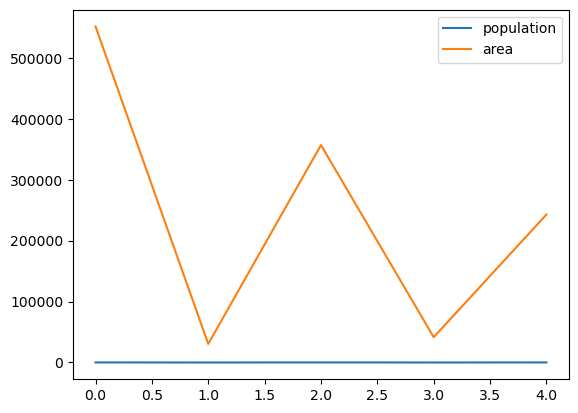

In [ ]:
countries.plot()

However, for this dataset, it does not say that much:

In [ ]:
countries

,country,population,area,capital
0,France,68.07,551695,Paris
1,Belgium,11.68,30528,Brussels
2,Germany,84.36,357022,Berlin
3,Netherlands,17.96,41526,Amsterdam
4,United Kingdom,67.22,242900,London


<Axes: >

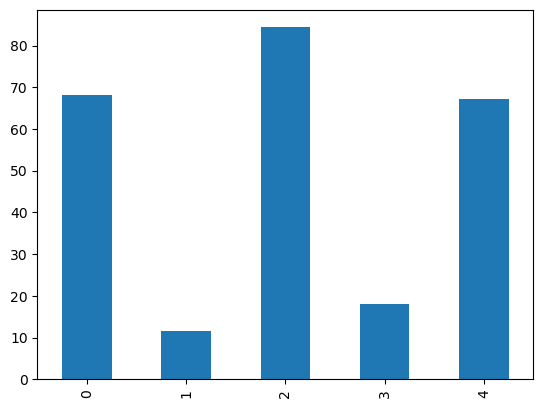

In [ ]:
countries['population'].plot(kind='bar')

NB: without specification the x are the indexes

**Exercice:**

>Vous pouvez jouer avec les mots clés de la fonction `plot`: **line, bar, hist, density, area, pie, scatter, hexbin**

In [ ]:
countries.plot?


<Axes: xlabel='country'>

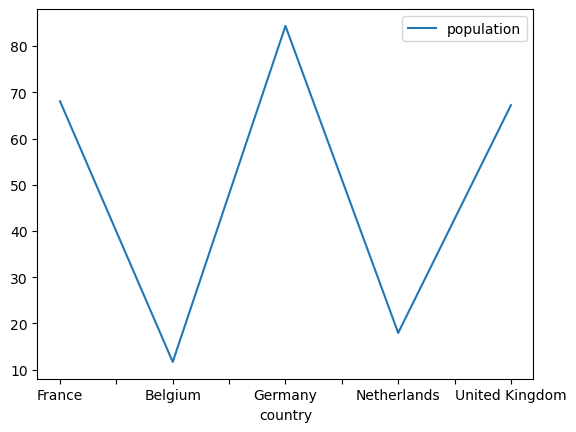

In [ ]:
countries.plot(x='country', y='population')

<Axes: xlabel='country'>

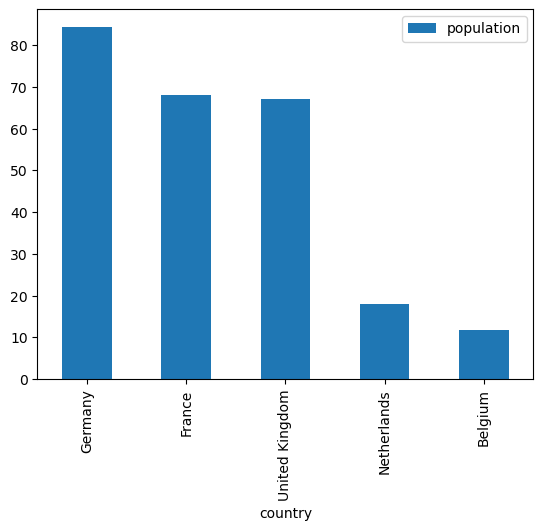

In [ ]:
countries.sort_values(by='population', ascending=False).plot(x='country', y='population', kind='bar')

In [131]:
pd.Series?

Init signature:
pd.Series(
    data=None,
    index=None,
    dtype: 'Dtype | None' = None,
    name=None,
    copy: 'bool | None' = None,
    fastpath: 'bool' = False,
) -> 'None'
Docstring:     
One-dimensional ndarray with axis labels (including time series).

Labels need not be unique but must be a hashable type. The object
supports both integer- and label-based indexing and provides a host of
methods for performing operations involving the index. Statistical
methods from ndarray have been overridden to automatically exclude
missing data (currently represented as NaN).

Operations between Series (+, -, /, \*, \*\*) align values based on their
associated index values-- they need not be the same length. The result
index will be the sorted union of the two indexes.

Parameters
----------
data : array-like, Iterable, dict, or scalar value
    Contains data stored in Series. If data is a dict, argument order is
    maintained.
index : array-like or Index (1d)
    Values must be hashable

In [132]:
population = pd.Series({'Germany': 81.3, 'Belgium': 11.3, 'France': 64.3, 
                        'United Kingdom': 64.9, 'Netherlands': 16.9})
population

Germany           81.3
Belgium           11.3
France            64.3
United Kingdom    64.9
Netherlands       16.9
dtype: float64

In [133]:
dico = {'country': ['France', 'Belgium', 'Germany', 'Netherlands', 'United Kingdom'],
        'population': [68.07, 11.68, 84.36, 17.96, 67.22],
        'area': [551695, 30528, 357022, 41526, 242900],
        'capital': ['Paris', 'Brussels', 'Berlin', 'Amsterdam', 'London']}

countries = pd.DataFrame(dico)

countries = countries.set_index('country')

In [134]:
countries.head()

,population,area,capital
country,,,
France,68.07,551695,Paris
Belgium,11.68,30528,Brussels
Germany,84.36,357022,Berlin
Netherlands,17.96,41526,Amsterdam
United Kingdom,67.22,242900,London


# Selecting and indexing data:

## Selecting data

**ATTENTION!:**

One of pandas' basic features is the labeling of rows and columns, but this makes indexing also a bit more complex compared to numpy. <br><br> We now have to distuinguish between:

- selection by **label**  
- selection by **position**

### `data[]` 

It provides some convenience shortcuts 

For a DataFrame, basic indexing selects the columns (cfr. the dictionaries of pure python)

Selecting a **single column**:

In [ ]:
# single []

countries['area']

country
France            551695
Belgium            30528
Germany           357022
Netherlands        41526
United Kingdom    242900
Name: area, dtype: int64

or multiple **columns**:

In [ ]:
# double [[]]

countries[['area', 'population']]

,area,population
country,,
France,551695,68.07
Belgium,30528,11.68
Germany,357022,84.36
Netherlands,41526,17.96
United Kingdom,242900,67.22


But, slicing accesses the **rows**:

In [ ]:
countries['France':'Netherlands']

,population,area,capital
country,,,
France,68.07,551695,Paris
Belgium,11.68,30528,Brussels
Germany,84.36,357022,Berlin
Netherlands,17.96,41526,Amsterdam


**ATTENTION:** Contrairement au *slicing* de numpy, le label de fin est **<u>inclus !</u>**

**EN RESUME**

Donc pour résumer: `[]` fournit les raccourcis suivants pour plus de commodité:

- **Series**: selecting a **label**: `s[label]`  

- **DataFrame**: selecting a single or multiple **columns**: `df['col']` or `df[['col1', 'col2']]`  

- **DataFrame**: slicing the **rows**: `df['row_label1':'row_label2']` or `df[mask]`  


### `loc[]` and `iloc[]`

Systematic indexing with `loc` and `iloc`

When using `[]` like above, you can only select from one axis at once (rows or columns, not both). For more advanced indexing, you have some extra attributes:
    
* `loc`: selection by label
* `iloc`: selection by position

Selecting a single element:

In [ ]:
countries.loc['Germany', 'area']

357022

`.loc[]`

Dans Pandas, la méthode .loc est utilisée pour accéder et modifier les éléments d'un DataFrame en fonction de leurs étiquettes (labels) de lignes et de colonnes. C'est l'une des méthodes les plus importantes et les plus couramment utilisées dans Pandas pour la sélection et la manipulation de données.

Exemple: accéder à la valeur du DataFrame : population de la France

In [ ]:
countries.loc['France','population']

68.07

In [ ]:
population = pd.Series({'Germany': 84.36, 'Belgium': 11.68, 'France': 68.07, 
                        'United Kingdom': 67.22, 'Netherlands': 17.96})
population

Germany           84.36
Belgium           11.68
France            68.07
United Kingdom    67.22
Netherlands       17.96
dtype: float64

In [ ]:
dico = {'country': ['France', 'Belgium', 'Germany', 'Netherlands', 'United Kingdom'],
        'population': [68.07, 11.68, 84.36, 17.96, 67.22],
        'area': [551695, 30528, 357022, 41526, 242900],
        'capital': ['Paris', 'Brussels', 'Berlin', 'Amsterdam', 'London']}

countries = pd.DataFrame(dico)

countries = countries.set_index('country')

countries

,population,area,capital
country,,,
France,68.07,551695,Paris
Belgium,11.68,30528,Brussels
Germany,84.36,357022,Berlin
Netherlands,17.96,41526,Amsterdam
United Kingdom,67.22,242900,London


Setting the index to the country names:

But the row or column indexer can also be a list, slice, boolean array (see next section), ..

In [ ]:
countries.loc['France':'Germany', ['area', 'population']]

,area,population
country,,
France,551695,68.07
Belgium,30528,11.68
Germany,357022,84.36


---
Selecting by position with `iloc` works similar as **indexing numpy arrays**:

In [ ]:
countries.iloc[0:2,1:3]

,area,capital
country,,
France,551695,Paris
Belgium,30528,Brussels


The different indexing methods can also be used to assign data:

In [ ]:
countries2 = countries.copy()

countries2.loc['Belgium':'Germany', 'population'] = 10

In [ ]:
countries2

,population,area,capital
country,,,
France,68.07,551695,Paris
Belgium,10.00,30528,Brussels
Germany,10.00,357022,Berlin
Netherlands,17.96,41526,Amsterdam
United Kingdom,67.22,242900,London


**RAPPEL:**

Advanced indexing with **loc** and **ïloc**

- **loc**: select by label: `df.loc[row_indexer, column_indexer]`

- **iloc**: select by position: `df.iloc[row_indexer, column_indexer]`


### Boolean indexing

Filtering with the boolean indexing

Often, you want to select rows based on a certain condition. This can be done with 'boolean indexing' (like a where clause in SQL) and comparable to numpy. 

The indexer (or boolean mask) should be 1-dimensional and the same length as the thing being indexed.

In [ ]:
countries['area'] > 100000

country
France             True
Belgium           False
Germany            True
Netherlands       False
United Kingdom     True
Name: area, dtype: bool

In [ ]:
countries[countries['area'] > 100000]

,population,area,capital
country,,,
France,68.07,551695,Paris
Germany,84.36,357022,Berlin
United Kingdom,67.22,242900,London


In [ ]:
# Filtering with a mask and a loc selection:

mask = countries['population'] > 40

countries.loc[mask, :]

,population,area,capital,log_population
country,,,,
France,68.07,551695,Paris,4.220537
Germany,84.36,357022,Berlin,4.435093
United Kingdom,67.22,242900,London,4.207971


**Filtrer des lignes:**

Syntaxe simple:  

`DataFrame[condition]`

Exemple: afficher les pays dont la population dépasse les 40 millions d'habitants

In [ ]:
countries[countries['population'] > 40]

,population,area,capital,density
country,,,,
France,68.07,551695,Paris,123.4
Germany,84.36,357022,Berlin,236.3
United Kingdom,67.22,242900,London,276.7


**Filtrer des lignes:**

Syntaxe utilisant un mask permet d'isoler la condition pour plus de lisibilité:  

`mask = condition`  

`DataFrame[mask]`

In [ ]:
# Filtering with a mask:

mask = countries['population'] > 40

countries[mask]

,population,area,capital,density
country,,,,
France,68.07,551695,Paris,123.4
Germany,84.36,357022,Berlin,236.3
United Kingdom,67.22,242900,London,276.7


<div class="alert alert-success">
<b>EXERCISE</b>:

<ul>
    <li>Add density as column to the DataFrame</li>
</ul>
</div>

<div class="alert alert-success">
<b>EXERCISE</b>:

 <ul>
  <li>Select the capital and the population column of those countries where the density is larger than 300</li>
</ul>
</div>

<div class="alert alert-success">

<b>EXERCISE</b>:

 <ul>
  <li>Add a column 'density_ratio' with the ratio of the density to the mean density</li>
</ul>
</div>

<div class="alert alert-success">

<b>EXERCISE</b>:

 <ul>
  <li>Change the capital of the UK to Cambridge</li>
</ul>
</div>

<div class="alert alert-success">
<b>EXERCISE</b>:

 <ul>
  <li>Select all countries whose population density is between 100 and 300 people/km²</li>
</ul>
</div>

#  Basic operations

Basic operations on Series and DataFrames  

Opérations de base sur les Series et les DataFrames

As you play around with DataFrames, you'll notice that many operations which work on NumPy arrays will also work on dataframes.

En manipulant des DataFrames vous remarquerez que de nombreuses opérations qui fonctionnent sur les NumPy array fonctionnent également sur les DataFrames.

## Elementwise-operations 

Les opérations élémentaires *Elementwise-operations* dans Pandas sont des opérations qui sont appliquées à chaque élément d'une série ou d'un DataFrame

Just like with numpy arrays, many operations are element-wise:

In [135]:
population

Germany           81.3
Belgium           11.3
France            64.3
United Kingdom    64.9
Netherlands       16.9
dtype: float64

In [136]:
population / 100

Germany           0.813
Belgium           0.113
France            0.643
United Kingdom    0.649
Netherlands       0.169
dtype: float64

`sort_values()`

La méthode sort_values() de Pandas est utilisée pour trier les données d'un DataFrame en fonction d'une ou plusieurs colonnes.  
Elle renvoie un nouveau DataFrame trié, laissant le DataFrame d'origine inchangé. Elle est très utilisée c'est pourquoi nous avons décidé de l'inclure à cette section sur les opérations élémentaires même si ce n'est pas une opération élémentaire car elle ne s'applique à l'ensemble des éléments d'une colonne et donc non pas élément par élément.

In [138]:
# sort by default ascending (France last highest area)

area = countries['area'].sort_values(ascending=False)

area

country
France            551695
Germany           357022
United Kingdom    242900
Netherlands        41526
Belgium            30528
Name: area, dtype: int64

**Exercice:**
> Calculer la densité de population (nombre d'habitants par km2)

SOLUTION

In [139]:
density = countries['population'] * 1000000 / countries['area']

In [140]:
density

country
France            123.383391
Belgium           382.599581
Germany           236.287960
Netherlands       432.500120
United Kingdom    276.739399
dtype: float64

**Exercice:**
> Trier cette densité de population de façon ascendante

SOLUTION

In [142]:
density.sort_values()

country
France            123.383391
Germany           236.287960
United Kingdom    276.739399
Belgium           382.599581
Netherlands       432.500120
dtype: float64

In [214]:
np.log(countries['population'])

country
France            4.220537
Belgium           2.457878
Germany           4.435093
Netherlands       2.888147
United Kingdom    4.207971
Name: population, dtype: float64

which can be added as a new column, as follows:

que l'on peut ajouter en tant que nouvelle colonne:

In [215]:
countries["log_population"] = np.log(countries['population'])

In [216]:
countries.columns

Index(['population', 'area', 'capital', 'log_population'], dtype='object')

In [217]:
countries.head(3)

,population,area,capital,log_population
country,,,,
France,68.07,551695,Paris,4.220537
Belgium,11.68,30528,Brussels,2.457878
Germany,84.36,357022,Berlin,4.435093


**Exercice:**
> Ajouter au DataFrame 'countries' une colonne 'density' contenant les densités de population
> On pourra arrondir les valeurs de 'density'

SOLUTION

In [154]:
countries['density'] = density

countries

,population,area,capital,density
country,,,,
France,68.07,551695,Paris,123.383391
Belgium,11.68,30528,Brussels,382.599581
Germany,84.36,357022,Berlin,236.287960
Netherlands,17.96,41526,Amsterdam,432.500120
United Kingdom,67.22,242900,London,276.739399


In [155]:
countries['density'] = density.round(1)

countries

,population,area,capital,density
country,,,,
France,68.07,551695,Paris,123.4
Belgium,11.68,30528,Brussels,382.6
Germany,84.36,357022,Berlin,236.3
Netherlands,17.96,41526,Amsterdam,432.5
United Kingdom,67.22,242900,London,276.7


`.apply()`

When you have an operation which does NOT work element-wise or you have no idea how to do it directly in Pandas, use the **apply()** method  

A typical use case is with a custom written or a **lambda** function

Lorsque vous avez une opération qui ne fonctionne pas de manière élémentaire ou que vous n'avez aucune idée de la façon de la faire directement dans Pandas, utilisez la méthode **apply()**.

Un cas d'utilisation typique est avec une fonction personnalisée ou une fonction lambda.

**Exemple**: annoter la population selon qu'elle dépasse ou non les 50 millions d'habitants

<u>Etape 1:</u> on créé une fonction qui retourne 'large' si la population dépasse les 50 millions et 'small' sinon:

In [165]:
def population_annotater(population):
    """annotate as large or small"""
    if population > 50:
        return 'large'
    else:
        return 'small'

<u>Etape 2:</u> On applique cette fonction 'apply()' à la colonne du DataFrame concerné

In [ ]:
# a custom user function

countries["population"].apply(population_annotater)

country
France            large
Belgium           small
Germany           large
Netherlands       small
United Kingdom    large
Name: population, dtype: object

**Exercice:**

> Créer une colonne qui contiendra le nombre de lettres de la capitale du pays

In [171]:
# in case you forgot the functionality: 
# countries["capital"].str.len()

countries["capital"].apply(lambda x: len(x))

country
France            5
Belgium           8
Germany           6
Netherlands       9
United Kingdom    6
Name: capital, dtype: int64

**Exercice:**

> Créer une colonne qui contiendra le logarithme népérien de la population si la densité est supérieure à 0,0002 millions d'habitants au km2 et sinon la population

Etape 1: on créé la fonction

In [167]:
def func(x):
    if x["population"] / x['area'] > 0.0002:
        return np.log(x["population"])
    return x["population"]

Etape 2: on l'applique

In [169]:
countries

,population,area,capital,density
country,,,,
France,68.07,551695,Paris,123.4
Belgium,11.68,30528,Brussels,382.6
Germany,84.36,357022,Berlin,236.3
Netherlands,17.96,41526,Amsterdam,432.5
United Kingdom,67.22,242900,London,276.7


In [170]:
# but this works as well element-wise...

countries.apply(func, axis=1)

country
France            68.070000
Belgium            2.457878
Germany            4.435093
Netherlands        2.888147
United Kingdom     4.207971
dtype: float64

Le paramètre `axis=1` est utilisé pour spécifier que l'on souhaite appliquer la fonction func à chaque ligne (c'est-à-dire à chaque élément de l'axe 1) plutôt qu'à chaque colonne (qui serait l'axe 0).

Si vous omettez le paramètre axis=1, la fonction apply() appliquera la fonction func à chaque colonne du DataFrame countries au lieu de chaque ligne. 

**Exercice:**

> Calculer les nombres de la population relativement à la France

In [244]:
countries['population'] / countries['population']['France']

country
France            1.000000
Belgium           0.171588
Germany           1.239312
Netherlands       0.263846
United Kingdom    0.987513
Name: population, dtype: float64

**Exercice:**

> Calculer la densité en utilisant les colonnes countries['population'] et countries['area']

In [173]:
countries['density_v2'] = countries['population']*1000000 / countries['area']

countries

,population,area,capital,density,density_v2
country,,,,,
France,68.07,551695,Paris,123.4,123.383391
Belgium,11.68,30528,Brussels,382.6,382.599581
Germany,84.36,357022,Berlin,236.3,236.287960
Netherlands,17.96,41526,Amsterdam,432.5,432.500120
United Kingdom,67.22,242900,London,276.7,276.739399


<b color='red'>ATTENTION</b> : Alignement (contrairement à numpy)

Faites attention à **l'alignement** : les opérations entre séries seront alignées sur l'index.

Cela signifie que si deux séries ont des index différents, les valeurs seront automatiquement alignées en fonction des index lors d'une opération, ce qui peut conduire à des résultats inattendus ou erronés.

Par exemple, si l'on additionne deux séries ayant des index différents, les valeurs correspondant aux index communs seront additionnées, tandis que les valeurs correspondant aux index non communs seront remplies de valeurs manquantes (NaN). Il est donc important de vérifier que les index des séries sont correctement alignés avant d'effectuer des opérations.

In [180]:
population[['Belgium']]

Belgium    11.3
dtype: object

In [181]:
s1 = population[['Belgium']]
s2 = population[['France']]

In [182]:
s1

Belgium    11.3
dtype: object

In [183]:
s2

France    64.3
dtype: object

In [184]:
s1 + s2

Belgium    NaN
France     NaN
dtype: object

## Aggregations (reductions)

Pandas provides a large set of **summary** functions that operate on different kinds of pandas objects (DataFrames, Series, Index) and produce single value. When applied to a DataFrame, the result is returned as a pandas Series (one value for each column). 

The average population number:

In [257]:
population.mean()

47.739999999999995

The minimum area:

In [259]:
countries['area'].mean()

244734.2

In [260]:
countries['area'].min()

30528

For dataframes, often only the numeric columns are included in the result:

In [270]:
countries['area'].median()

244820.0

# D'autres méthodes utiles

Some other essential methods: `isin` and `string` methods

The `isin` method of Series is very useful to select rows that may contain certain values:

In [ ]:
s = countries['capital']

In [ ]:
s.isin?

In [ ]:
s.isin(['Berlin', 'London'])

This can then be used to filter the dataframe with boolean indexing:

In [ ]:
countries[countries['capital'].isin(['Berlin', 'London'])]

Let's say we want to select all data for which the capital starts with a 'B'. In Python, when having a string, we could use the `startswith` method:

In [ ]:
'Berlin'.startswith('B')

In pandas, these are available on a Series through the `str` namespace:

In [ ]:
countries['capital'].str.startswith('B')

For an overview of all string methods, see: http://pandas.pydata.org/pandas-docs/stable/api.html#string-handling

**Exercice:**

> Sélectionner tous les pays qui ont un nom de capital avec plus de 7 caractères

**Exercice:**

> Sélectionner tous les pays qui ont un nom de capital contenant la séquence de caractères 'am'

# Pitfall: chained indexing

**Piège : l'indexation en chaîne (et l'avertissement 'SettingWithCopyWarning')**.

L'indexation en chaîne est une pratique à éviter dans Pandas, car elle peut conduire à des résultats inattendus ou à des erreurs. Cela se produit lorsque l'on utilise plusieurs niveaux d'indexation pour sélectionner des éléments dans un DataFrame, en les chaînant les uns à la suite des autres.

L'avertissement 'SettingWithCopyWarning' est un message d'avertissement qui peut s'afficher lorsque l'on utilise l'indexation en chaîne ou d'autres méthodes de sélection dans Pandas. Cela indique que l'on est en train de modifier une copie du DataFrame plutôt que le DataFrame original, ce qui peut également conduire à des résultats inattendus ou à des erreurs.

En résumé, l'indexation en chaîne et l'avertissement 'SettingWithCopyWarning' sont des pièges à éviter dans Pandas, car ils peuvent rendre le code instable et difficile à déboguer.

In [188]:
countries.loc['Belgium', 'capital'] = 'Paris'

In [189]:
countries

,population,area,capital
country,,,
France,68.07,551695,Paris
Belgium,11.68,30528,Paris
Germany,84.36,357022,Berlin
Netherlands,17.96,41526,Amsterdam
United Kingdom,67.22,242900,London


In [190]:
countries['capital']['Belgium'] = 'Lyon' 

/var/folders/tb/_m1wm0vd633_w2zg_9vw_19m0000gn/T/ipykernel_6104/1480041082.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  countries['capital']['Belgium'] = 'Lyon'


In [191]:
countries

,population,area,capital
country,,,
France,68.07,551695,Paris
Belgium,11.68,30528,Lyon
Germany,84.36,357022,Berlin
Netherlands,17.96,41526,Amsterdam
United Kingdom,67.22,242900,London


In [192]:
countries[countries['capital'] == 'Lyon']['capital'] = 'Brussels' 

/var/folders/tb/_m1wm0vd633_w2zg_9vw_19m0000gn/T/ipykernel_6104/853849109.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  countries[countries['capital'] == 'Lyon']['capital'] = 'Brussels'


In [193]:
countries

,population,area,capital
country,,,
France,68.07,551695,Paris
Belgium,11.68,30528,Lyon
Germany,84.36,357022,Berlin
Netherlands,17.96,41526,Amsterdam
United Kingdom,67.22,242900,London


**RAPPEL:**  

Que faire lorsque l'on rencontre l'erreur "value is trying to be set on a copy of a slice from a DataFrame" ?

- Use `loc` instead of chained indexing **if possible**!

- Or `copy` explicitly if you don't want to change the original data.

# Working with time series data

## Introduction: `datetime` module

Standard Python contains the `datetime` module to handle with date and time data:

In [196]:
import datetime

In [197]:
dt = datetime.datetime(year=2016, month=12, day=19, hour=13, minute=30)

dt

datetime.datetime(2016, 12, 19, 13, 30)

In [198]:
print(dt) # .day,...

2016-12-19 13:30:00


In [199]:
print(dt.day, dt.year, dt.month)

19 2016 12


In [200]:
print(dt.strftime("%d %B %Y"))

19 December 2016


## Dates and times in pandas

### The ``Timestamp`` object

Pandas has its own date and time objects, which are compatible with the standard `datetime` objects, but provide some more functionality to work with.  

The `Timestamp` object can also be constructed from a string:

In [201]:
ts = pd.Timestamp('2016-12-19')
ts

Timestamp('2016-12-19 00:00:00')

Like with `datetime.datetime` objects, there are several useful attributes available on the `Timestamp`. For example, we can get the month:

In [202]:
ts.month

12

In [203]:
pd.Timedelta('5 days')

Timedelta('5 days 00:00:00')

In [204]:
ts + pd.Timedelta('5 days')

Timestamp('2016-12-24 00:00:00')

### Parsing datetime strings 

![](http://imgs.xkcd.com/comics/iso_8601.png)


Unfortunately, when working with real world data, you encounter many different `datetime` formats. Most of the time when you have to deal with them, they come in text format, e.g. from a `CSV` file. To work with those data in Pandas, we first have to *parse* the strings to actual `Timestamp` objects.

**SE RAPPELER:**

La fonction `pd.to_datetime()` permet de convertir des chaînes de caractères représentant des dates et/ou es heures en objets Timestamp

from string formatted dates to Timestamp objects: `pd.to_datetime` function

In [221]:
pd.to_datetime("2016-12-09")

Timestamp('2016-12-09 00:00:00')

In [222]:
pd.to_datetime("09/12/2016")

Timestamp('2016-09-12 00:00:00')

In [223]:
pd.to_datetime("09/12/2016", dayfirst=True)

Timestamp('2016-12-09 00:00:00')

In [224]:
pd.to_datetime("09/12/2016", format="%d/%m/%Y")

Timestamp('2016-12-09 00:00:00')

In [225]:
pd.to_datetime("2016-12-09", format="%Y-%m-%d")

Timestamp('2016-12-09 00:00:00')

A detailed overview of how to specify the `format` string, see the table in the python documentation: https://docs.python.org/3.5/library/datetime.html#strftime-and-strptime-behavior

### `Timestamp` data in a Series or DataFrame column

In [226]:
s = pd.Series(['2016-12-09 10:00:00',
               '2016-12-09 11:00:00',
               '2016-12-09 12:00:00'])

In [227]:
s

0    2016-12-09 10:00:00
1    2016-12-09 11:00:00
2    2016-12-09 12:00:00
dtype: object

The `to_datetime` function can also be used to convert a full series of strings:

In [228]:
ts = pd.to_datetime(s)

In [229]:
ts

0   2016-12-09 10:00:00
1   2016-12-09 11:00:00
2   2016-12-09 12:00:00
dtype: datetime64[ns]

Notice the data type of this series: the `datetime64[ns]` dtype. This indicates that we have a series of actual datetime values.

The same attributes as on single `Timestamp`s are also available on a Series with datetime data, using the **`.dt`** accessor:

In [230]:
ts.dt.hour

0    10
1    11
2    12
dtype: int32

In [231]:
ts.dt.weekday

0    4
1    4
2    4
dtype: int32

To quickly construct some regular time series data, the [``pd.date_range``](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.date_range.html) function comes in handy:

In [232]:
pd.Series(pd.date_range(start="2016-01-01", periods=10, freq='3H'))

0   2016-01-01 00:00:00
1   2016-01-01 03:00:00
2   2016-01-01 06:00:00
3   2016-01-01 09:00:00
4   2016-01-01 12:00:00
5   2016-01-01 15:00:00
6   2016-01-01 18:00:00
7   2016-01-01 21:00:00
8   2016-01-02 00:00:00
9   2016-01-02 03:00:00
dtype: datetime64[ns]

In [233]:
pd.Series(pd.date_range(start="2016-01-01", periods=10, freq='1D'))

0   2016-01-01
1   2016-01-02
2   2016-01-03
3   2016-01-04
4   2016-01-05
5   2016-01-06
6   2016-01-07
7   2016-01-08
8   2016-01-09
9   2016-01-10
dtype: datetime64[ns]

# Time series data: `Timestamp` in the index

## River discharge example data

For the following demonstration of the time series functionality, we use a sample of discharge data of the Maarkebeek (Flanders) with 3 hour averaged values, derived from the [Waterinfo website](https://www.waterinfo.be/).

In [260]:
url = 'https://www.hkex.com.hk/eng/dwrc/search/dwFullList.csv'

data = pd.read_csv(url, encoding = 'utf-16', sep = '\t', skiprows=1, skipfooter = 3, engine = 'python')

data.head(2)

,DW Code,Issuer,UL,Call/Put,DW Type,Listing,Maturity,Strike Currency,Strike,Entitlement Ratio^,Total Issue Size,O/S (%),Delta (%),IV. (%),Trading Currency,Day High,Day Low,Closing Price,T/O ('000),UL Currency,UL Price
10002,GS,DJI,Put,Standard,14-08-2023,20-09-2024,-,30000.0,58000.0,"100,000,000",19.79,(0.000),27.861,HKD,0.011,0.011,0.011,3,-,-,NaN
10007,JP,DJI,Put,Standard,18-08-2023,20-09-2024,-,29850.0,58000.0,"150,000,000",35.93,(0.000),27.792,HKD,0.000,0.000,0.010,0,-,-,NaN


In [261]:
data = data.shift(axis=1)

In [265]:
data_new = data.reset_index().drop('DW Code', axis=1).rename(columns={'index': 'DW Code'})


In [266]:
data_new.head(2)

,DW Code,Issuer,UL,Call/Put,DW Type,Listing,Maturity,Strike Currency,Strike,Entitlement Ratio^,Total Issue Size,O/S (%),Delta (%),IV. (%),Trading Currency,Day High,Day Low,Closing Price,T/O ('000),UL Currency,UL Price
0,10002,GS,DJI,Put,Standard,14-08-2023,20-09-2024,-,30000.0,58000.0,"100,000,000",19.79,(0.000),27.861,HKD,0.011,0.011,0.011,3,-,-
1,10007,JP,DJI,Put,Standard,18-08-2023,20-09-2024,-,29850.0,58000.0,"150,000,000",35.93,(0.000),27.792,HKD,0.000,0.000,0.010,0,-,-


In [267]:
data.columns

Index(['DW Code', 'Issuer', 'UL', 'Call/Put', 'DW Type', 'Listing', 'Maturity',
       'Strike Currency', 'Strike', 'Entitlement Ratio^', 'Total Issue Size',
       'O/S (%)', 'Delta (%)', 'IV. (%)', 'Trading Currency', 'Day High',
       'Day Low', 'Closing Price', 'T/O ('000)', 'UL Currency', 'UL Price'],
      dtype='object')

In [268]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5297 entries, 10002 to 29951
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DW Code             0 non-null      object 
 1   Issuer              5297 non-null   object 
 2   UL                  5297 non-null   object 
 3   Call/Put            5297 non-null   object 
 4   DW Type             5297 non-null   object 
 5   Listing             5297 non-null   object 
 6   Maturity            5297 non-null   object 
 7   Strike Currency     5297 non-null   object 
 8   Strike              5297 non-null   float64
 9   Entitlement Ratio^  5297 non-null   float64
 10  Total Issue Size    5297 non-null   object 
 11  O/S (%)             5297 non-null   object 
 12  Delta (%)           5297 non-null   object 
 13  IV. (%)             5297 non-null   object 
 14  Trading Currency    5297 non-null   object 
 15  Day High            5297 non-null   object 
 16  Day Lo

We already know how to parse a date column with Pandas:

In [245]:
data['DW Type'] = pd.to_datetime(data['DW Type'], format = '%d-%m-%Y')

In [246]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5297 entries, 10002 to 29951
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   DW Code             5297 non-null   object        
 1   Issuer              5297 non-null   object        
 2   UL                  5297 non-null   object        
 3   Call/Put            5297 non-null   object        
 4   DW Type             5297 non-null   datetime64[ns]
 5   Listing             5297 non-null   object        
 6   Maturity            5297 non-null   object        
 7   Strike Currency     5297 non-null   float64       
 8   Strike              5297 non-null   float64       
 9   Entitlement Ratio^  5297 non-null   object        
 10  Total Issue Size    5297 non-null   object        
 11  O/S (%)             5297 non-null   object        
 12  Delta (%)           5297 non-null   object        
 13  IV. (%)             5297 non-null   object      

With `set_index('datetime')`, we set the column with datetime values as the index, which can be done by both `Series` and `DataFrame`.

In [ ]:
data = data.set_index("Time")

In [ ]:
data

The steps above are provided as built-in functionality of `read_csv`:

In [ ]:
data = pd.read_csv("data/vmm_flowdata.csv", index_col=0, parse_dates=True)

In [ ]:
data.head()

## The DatetimeIndex

When we ensure the DataFrame has a `DatetimeIndex`, time-series related functionality becomes available:

In [ ]:
data.index

Similar to a Series with datetime data, there are some attributes of the timestamp values available:

In [ ]:
data.index.day

In [ ]:
data.index.dayofyear

In [ ]:
data.index.year

The `plot` method will also adapt it's labels (when you zoom in, you can see the different levels of detail of the datetime labels):


In [ ]:
data.plot()

We have to much data to sensibly plot on one figure. Let's see how we can easily select part of the data or aggregate the data to other time resolutions in the next sections.

## Selecting data from a time series

We can use label based indexing on a timeseries as expected:

In [ ]:
data[pd.Timestamp("2012-01-01 09:00"):pd.Timestamp("2012-01-01 19:00")]

But, for convenience, indexing a time series also works with strings:

In [ ]:
data["2012-01-01 09:00":"2012-01-01 19:00"]

A nice feature is **"partial string" indexing**, where we can do implicit slicing by providing a partial datetime string.

E.g. all data of 2013:

In [ ]:
data['2013']

Normally you would expect this to access a column named '2013', but as for a DatetimeIndex, pandas also tries to interprete it as a datetime slice.

Or all data of January up to March 2012:

In [ ]:
data['2012-01':'2012-03']

**Exercice:**

> Sélectionner toutes les données commencçant depuis 2018

**Exercice:**

> Sélectionner toutes les données de janvier pour les différentes années

**Exercice:**

> Sélectionner toutes les données de janvier, février et mars pour les différentes années

## The power of pandas: `resample`

A very powerfull method is **`resample`: converting the frequency of the time series** (e.g. from hourly to daily data).

The time series has a frequency of 1 hour. I want to change this to daily:

In [ ]:
data.resample('D').mean().head()

Other mathematical methods can also be specified:

In [ ]:
data.resample('D').max().head()

**Se souvenir:**

- The string to specify the new time frequency: http://pandas.pydata.org/pandas-docs/stable/timeseries.html#offset-aliases <br><br>
- These strings can also be combined with numbers, eg `'10D'`...

In [1]:
data.resample('1M').std().plot()

NameError: name 'data' is not defined

<div class="alert alert-success">

<b>EXERCISE</b>:

 <ul>
  <li>plot the monthly standard deviation of the columns</li>
</ul>
</div>

<div class="alert alert-success">

<b>EXERCISE</b>:
 <ul>
  <li>plot the monthly mean and median values for the years 2011-2012 for 'L06_347'<br><br></li>
 </ul>
     <b>Note** </b> <br>You can create a new figure with  `fig, ax = plt.subplots()`
 and add each of the plots to the created `ax` object (see documentation of pandas plot function)
</div>

<div class="alert alert-success">

<b>EXERCISE</b>:

 <ul>
  <li>plot the monthly mininum and maximum daily average value of the 'LS06_348' column</li>
</ul>
</div>

<div class="alert alert-success">
<b>EXERCISE</b>:

 <ul>
  <li>make a bar plot of the mean of the stations in year of 2013 (Remark: create a `fig, ax = plt.subplots()` object and add the plot to the created ax</li>
</ul>

</div>

## Combining datasets Part I - concat

Combining data is essential functionality in a data analysis workflow. 

Data is distributed in multiple files, different information needs to be merged, new data is calculated, .. and needs to be added together. Pandas provides various facilities for easily combining together Series and DataFrame objects

In [ ]:
# series
population = pd.Series({'Germany': 81.3, 'Belgium': 11.3, 'France': 64.3, 
                        'United Kingdom': 64.9, 'Netherlands': 16.9})

# dataframe
data = {'country': ['Belgium', 'France', 'Germany', 'Netherlands', 'United Kingdom'],
        'population': [11.3, 64.3, 81.3, 16.9, 64.9],
        'area': [30510, 671308, 357050, 41526, 244820],
        'capital': ['Brussels', 'Paris', 'Berlin', 'Amsterdam', 'London']}
countries = pd.DataFrame(data)
countries

# Adding columns

As we already have seen before, adding a single column is very easy:

In [ ]:
pop_density = countries['population'] * 1e6 / countries['area']

In [ ]:
pop_density

In [ ]:
countries['pop_density'] = pop_density

In [ ]:
countries

Adding multiple columns at once is also possible. For example, the following method gives us a DataFrame of two columns:

In [ ]:
countries["country"].str.split(" ", expand=True)

We can add both at once to the dataframe:

In [ ]:
countries[['first', 'last']] = countries["country"].str.split(" ", expand=True)

In [ ]:
countries

Delete the new columns to revert the change

In [ ]:
countries.drop(['first', 'last'], axis=1, inplace=True)
countries

# Concatenating data

The ``pd.concat`` function does all of the heavy lifting of combining data in different ways.

``pd.concat`` takes a list or dict of Series/DataFrame objects and concatenates them in a certain direction (`axis`) with some configurable handling of “what to do with the other axes”.


## Combining rows - ``pd.concat``

![](img/schema-concat0.svg)

Assume we have some similar data as in `countries`, but for a set of different countries:

In [ ]:
data = {'country': ['Nigeria', 'Rwanda', 'Egypt', 'Morocco', ],
        'population': [182.2, 11.3, 94.3, 34.4],
        'area': [923768, 26338 , 1010408, 710850],
        'capital': ['Abuja', 'Kigali', 'Cairo', 'Rabat']}
countries_africa = pd.DataFrame(data)
countries_africa 

We now want to combine the rows of both datasets:

In [ ]:
pd.concat([countries, countries_africa], sort=False)

If we don't want the index to be preserved:

In [ ]:
pd.concat([countries, countries_africa], ignore_index=True, sort=False)

When the two dataframes don't have the same set of columns, by default missing values get introduced:

In [ ]:
pd.concat([countries, countries_africa[['country', 'capital']]],
          ignore_index=True, sort=False)

We can also pass a dictionary of objects instead of a list of objects. Now the keys of the dictionary are preserved as an additional index level:

In [ ]:
pd.concat({'europe': countries, 'africa': countries_africa}, sort=False)

## Combining columns  - ``pd.concat`` with ``axis=1``

![](img/schema-concat1.svg)

Assume we have another DataFrame for the same countries, but with some additional statistics:

In [ ]:
data = {'country': ['Belgium', 'France', 'Netherlands'],
        'GDP': [496477, 2650823, 820726],
        'area': [8.0, 9.9, 5.7]}
country_economics = pd.DataFrame(data).set_index('country')
country_economics

In [ ]:
pd.concat([countries, country_economics], axis=1, sort=False)

`pd.concat` matches the different objects based on the index:

In [ ]:
countries2 = countries.set_index('country')

In [ ]:
countries2

In [ ]:
pd.concat([countries2, country_economics], axis=1, sort=False)

# Joining data with `pd.merge`

Using `pd.concat` above, we combined datasets that had the same columns or the same index values. But, another typical case if where you want to add information of second dataframe to a first one based on one of the columns. That can be done with [`pd.merge`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.merge.html).

Let's look again at the titanic passenger data, but taking a small subset of it to make the example easier to grasp:

In [ ]:
data = {'country': ['Belgium', 'France', 'Germany', 'Netherlands', 'United Kingdom', 'Australia'],
        'population': [11.3, 64.3, 81.3, 16.9, 64.9, 24.4],
        'area': [30510, 671308, 357050, 41526, 244820, 7692024],
        'capital': ['Brussels', 'Paris', 'Berlin', 'Amsterdam', 'London', 'Canberra'],
        'hemisphere': ['North', 'North', 'North', 'North', 'North', 'South']}
countries = pd.DataFrame(data)
countries

In [ ]:
data = {'city': ['Paris', 'Lyon', 'Lille', 'Berlin', 'Munich', 'Sydney'],
        'country': ['France', 'France', 'France', 'Germany', 'Germany', 'Australia'],
        }
cities = pd.DataFrame(data)
cities

Let's say we want to know in what hemisphere is each city

In [ ]:
pd.merge(cities, countries, on='country', how='left')

In [ ]:
pd.merge(cities, countries[['country', 'hemisphere']],
         on='country', how='left')

In this case we use `how='left` (a "left join") because we wanted to keep the original rows of `cities` and only add matching values from `countries` to it. Other options are 'inner', 'outer' and 'right' (see the [docs](http://pandas.pydata.org/pandas-docs/stable/merging.html#brief-primer-on-merge-methods-relational-algebra) for more on this).

## "Group by" operations

### Some 'theory': the groupby operation (split-apply-combine)

In [ ]:
df = pd.DataFrame({'key':['A','B','C','A','B','C','A','B','C'],
                   'data': [0, 5, 10, 5, 10, 15, 10, 15, 20]})
df

### Recap: aggregating functions

When analyzing data, you often calculate summary statistics (aggregations like the mean, max, ...). As we have seen before, we can easily calculate such a statistic for a Series or column using one of the many available methods. For example:

In [ ]:
df['data'].sum()

However, in many cases your data has certain groups in it, and in that case, you may want to calculate this statistic for each of the groups.

For example, in the above dataframe `df`, there is a column 'key' which has three possible values: 'A', 'B' and 'C'. When we want to calculate the sum for each of those groups, we could do the following:

In [ ]:
print('A', df[df['key'] == "A"]['data'].sum())
print('B', df[df['key'] == "B"]['data'].sum())
print('C', df[df['key'] == "C"]['data'].sum())

This becomes very verbose when having multiple groups. You could make the above a bit easier by looping over the different values, but still, it is not very convenient to work with.

What we did above, applying a function on different groups, is a "groupby operation", and pandas provides some convenient functionality for this.

### Groupby: applying functions per group

The "group by" concept: we want to **apply the same function on subsets of your dataframe, based on some key to split the dataframe in subsets**

This operation is also referred to as the "split-apply-combine" operation, involving the following steps:

* **Splitting** the data into groups based on some criteria
* **Applying** a function to each group independently
* **Combining** the results into a data structure

<img src="img/splitApplyCombine.png">

Similar to SQL `GROUP BY`

Instead of doing the manual filtering as above


    df[df['key'] == "A"].sum()
    df[df['key'] == "B"].sum()
    ...

pandas provides the `groupby` method to do exactly this:

In [ ]:
df.groupby('key').sum()

In [ ]:
df.groupby('key').aggregate(np.sum)  # 'sum'

And many more methods are available. 

In [ ]:
df.groupby('key')['data'].sum()

# Some more theory

## Specifying the grouper

In the previous example and exercises, we always grouped by a single column by passing its name. But, a column name is not the only value you can pass as the grouper in `df.groupby(grouper)`. Other possibilities for `grouper` are:

- a list of strings (to group by multiple columns)
- a Series (similar to a string indicating a column in df) or array
- function (to be applied on the index)
- dict : groups by values
- levels=[], names of levels in a MultiIndex

In [ ]:
df.groupby(df['data'] < 18).mean()

In [ ]:
url = 'https://raw.githubusercontent.com/glemaitre/ca_09_2020/master/01_pandas/data/referendum.csv'

df = pd.read_csv(url, sep=';')

In [ ]:
df.head()

,Department code,Department name,Town code,Town name,Registered,Abstentions,Null,Choice A,Choice B
0,1,AIN,1,L'Abergement-Clémenciat,592,84,9,154,345
1,1,AIN,2,L'Abergement-de-Varey,215,36,5,66,108
2,1,AIN,4,Ambérieu-en-Bugey,8205,1698,126,2717,3664
3,1,AIN,5,Ambérieux-en-Dombes,1152,170,18,280,684
4,1,AIN,6,Ambléon,105,17,1,35,52


`groupby()[]`

La méthode `groupby()` de Pandas est utilisée pour regrouper les données d'un DataFrame en fonction d'une ou plusieurs colonnes.  
Elle renvoie un objet DataFrameGroupBy qui peut être utilisé pour effectuer des opérations d'agrégation sur les groupes de données.

<u>Exemple:</u> compter le nombre d'abstentions par département

In [ ]:
df.groupby('Department name')['Abstentions'].sum()

Department name
AIN                               65996
AISNE                             72928
ALLIER                            45266
ALPES DE HAUTE PROVENCE           21034
ALPES MARITIMES                  153383
ARDECHE                           38560
ARDENNES                          40508
ARIEGE                            18502
AUBE                              37939
AUDE                              43641
AVEYRON                           32095
BAS RHIN                         150904
BOUCHES DU RHONE                 257432
CALVADOS                          82498
CANTAL                            20366
CHARENTE                          46641
CHARENTE MARITIME                 85478
CHER                              45295
CORREZE                           27332
CORSE SUD                         26173
COTE D'OR                         60284
COTES D'ARMOR                     64453
CREUSE                            17218
DEUX SEVRES                       43596
DORDOGNE                

## The size of groups - value counts

Oftentimes you want to know how many elements there are in a certain group (or in other words: the number of occurences of the different values from a column).

To get the size of the groups, we can use `size`:

In [ ]:
df.groupby('key').size()

Another way to obtain such counts, is to use the Series `value_counts` method:

In [ ]:
df['key'].value_counts()

## Reshaping data

### Pivoting data

People who know Excel, probably know the **Pivot** functionality:

![](img/pivot_excel.png)

The data of the table:

In [3]:
excelample = pd.DataFrame(
    {'Month': ["January", "January", "January", "January", 
               "February", "February", "February", "February", 
               "March", "March", "March", "March"],
     'Category': ["Transportation", "Grocery", "Household", "Entertainment",
                  "Transportation", "Grocery", "Household", "Entertainment",
                  "Transportation", "Grocery", "Household", "Entertainment"],
     'Amount': [74., 235., 175., 100., 115., 240., 225., 125., 90., 260., 200., 120.]})

In [4]:
excelample

,Month,Category,Amount
0,January,Transportation,74.0
1,January,Grocery,235.0
2,January,Household,175.0
3,January,Entertainment,100.0
4,February,Transportation,115.0
5,February,Grocery,240.0
6,February,Household,225.0
7,February,Entertainment,125.0
8,March,Transportation,90.0
9,March,Grocery,260.0


In [5]:
excelample_pivot = excelample.pivot(index="Category", columns="Month", values="Amount")
excelample_pivot

Month,February,January,March
Category,,,
Entertainment,125.0,100.0,120.0
Grocery,240.0,235.0,260.0
Household,225.0,175.0,200.0
Transportation,115.0,74.0,90.0


Interested in *Grand totals*?

In [6]:
# sum columns
excelample_pivot.sum(axis=1)

Category
Entertainment     345.0
Grocery           735.0
Household         600.0
Transportation    279.0
dtype: float64

In [7]:
# sum rows
excelample_pivot.sum(axis=0)

Month
February    705.0
January     584.0
March       670.0
dtype: float64

## Pivot is just reordering your data:

Small subsample of the titanic dataset:

In [8]:
df = pd.DataFrame({'Fare': [7.25, 71.2833, 51.8625, 30.0708, 7.8542, 13.0],
                   'Pclass': [3, 1, 1, 2, 3, 2],
                   'Sex': ['male', 'female', 'male', 'female', 'female', 'male'],
                   'Survived': [0, 1, 0, 1, 0, 1]})

In [9]:
df

,Fare,Pclass,Sex,Survived
0,7.2500,3,male,0
1,71.2833,1,female,1
2,51.8625,1,male,0
3,30.0708,2,female,1
4,7.8542,3,female,0
5,13.0000,2,male,1


In [10]:
df.pivot(index='Pclass', columns='Sex', values='Fare')

Sex,female,male
Pclass,,
1,71.2833,51.8625
2,30.0708,13.0000
3,7.8542,7.2500


In [11]:
df.pivot(index='Pclass', columns='Sex', values='Survived')

Sex,female,male
Pclass,,
1,1,0
2,1,1
3,0,0


<div class="alert alert-danger">

<b>NOTE</b>:

 <ul>
  <li>**Pivot** is purely restructering: a single value for each index/column combination is required.</li>
</ul>
</div>

## "unpivot" tables with melt


Melt “unpivots” a DataFrame from wide format to long format, optionally leaving identifier variables set.

In [ ]:
pd.melt(df.pivot(index='Pclass', columns='Sex', values='Survived'))

# Pivot tables - aggregating while pivoting

In [ ]:
df.pivot_table(index='Sex', columns='Pclass', values='Fare')

<div class="alert alert-info">

<b>REMEMBER</b>:

 <ul>
  <li>By default, `pivot_table` takes the **mean** of all values that would end up into one cell. However, you can also specify other aggregation functions using the `aggfunc` keyword.</li>
</ul>
</div>

In [ ]:
df.pivot_table(index='Sex', columns='Pclass', 
               values='Fare', aggfunc='max')

In [ ]:
df.pivot_table(index='Sex', columns='Pclass', 
               values='Fare', aggfunc='count')

# Reshaping with `stack` and `unstack`

The docs say:

> Pivot a level of the (possibly hierarchical) column labels, returning a
DataFrame (or Series in the case of an object with a single level of
column labels) having a hierarchical index with a new inner-most level
of row labels.

Indeed... 
<img src="img/schema-stack.svg" width=50%>

Before we speak about `hierarchical index`, first check it in practice on the following dummy example:

In [ ]:
df = pd.DataFrame({'A': ['one', 'one', 'two', 'two'], 
                   'B': ['a', 'b', 'a', 'b'], 
                   'C': range(4)})
df

To use `stack`/`unstack`, we need the values we want to shift from rows to columns or the other way around as the index:

In [ ]:
df = df.set_index(['A', 'B']) # Indeed, you can combine two indices
df

In [ ]:
result = df['C'].unstack()
result

In [ ]:
df = result.stack().reset_index(name='C')
df

<div class="alert alert-info">

<b>REMEMBER</b>:

 <ul>
  <li>**stack**: make your data *longer* and *smaller* </li>
  <li>**unstack**: make your data *shorter* and *wider* </li>
</ul>
</div>

## To learn more on Pandas and scientific Python in general

   - https://nbviewer.jupyter.org/github/jakevdp/PythonDataScienceHandbook/tree/master/notebooks/